# Circuit-Level Performance Heat Map

This notebook studies the same circuit-level decoding task as `run_bivariate_bicycle144_12_12_native_bpgd_cluster_Z_basis.py`, but restricted to a one-leg relay sweep so the effect of disordered memory can be visualized as a heat map.

Task definition:
- use the `bicycle_bivariate_144_12_12_memory_Z` Stim circuit
- apply the same `Z`-basis detector filtering as the cluster runner
- build the DEM and decoder matrices from that filtered circuit
- sample one fixed batch of physical fault shots from the filtered DEM
- decode those same shots repeatedly with a single relay leg
- vary only the disordered-memory interval `[center - width / 2, center + width / 2]`

Fixed relay settings are taken from the cluster runner defaults:
- `alpha = 1.0`
- `gamma0 = 0.15`
- `pre_iter = 80`
- `num_sets = 1`
- `set_max_iter = 60`
- `stop_nconv = 1`

At each `(center, width)` point:
- the same pre-sampled circuit-level shots are reused for fairness
- `random_draws_per_point` relay seeds are evaluated to average over disorder realizations
- results are aggregated over all sampled shots and relay draws

The reported metrics mirror the other performance notebooks:
- logical success rate
- convergence rate
- exact recovery rate
- mean iterations

In [1]:
import json
from pathlib import Path

from IPython import get_ipython
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import relay_bp
import stim
from tqdm.auto import tqdm

from relay_bp.stim import CheckMatrices
from relay_bp.stim.sinter.runner import _filter_detectors_by_basis

_ip = get_ipython()
if _ip is not None:
    try:
        _ip.run_line_magic("matplotlib", "inline")
    except Exception:
        pass

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 200)
np.set_printoptions(edgeitems=20, linewidth=160, suppress=True)

c:\Users\User\Documents\projects-git\relay_mother_folder\relay\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "tests" / "testdata" / "bicycle_bivariate").exists():
            return candidate
    raise FileNotFoundError(
        "Could not find repo root containing tests/testdata/bicycle_bivariate "
        f"starting from {start}."
    )


def parse_name_metadata(path: Path) -> dict[str, object]:
    metadata: dict[str, object] = {"stim_path": str(path)}
    for part in path.stem.split(","):
        if "=" not in part:
            continue
        key, value = part.split("=", 1)
        metadata[key] = value
    if "error_rate" in metadata:
        metadata["p"] = float(metadata["error_rate"])
    return metadata


def find_circuit_path(circuits_dir: Path, selected_p: float) -> Path:
    wanted = str(selected_p)
    matches = []
    for path in sorted(circuits_dir.glob("circuit=bicycle_bivariate_144_12_12_memory_Z,*.stim")):
        metadata = parse_name_metadata(path)
        if metadata.get("error_rate") == wanted:
            matches.append(path)
    if not matches:
        raise FileNotFoundError(
            f"Missing bicycle_bivariate_144_12_12_memory_Z circuit for p={selected_p} in {circuits_dir}."
        )
    if len(matches) > 1:
        raise ValueError(
            f"Expected exactly one memory_Z circuit for p={selected_p}, got {len(matches)}."
        )
    return matches[0]


repo_root = find_repo_root(Path.cwd().resolve())
circuits_dir = repo_root / "tests" / "testdata" / "bicycle_bivariate"

basis_filter = "Z"
selected_p = 0.003
stim_path = find_circuit_path(circuits_dir, selected_p)

alpha = 1.0
gamma0 = 0.15
pre_iter = 80
num_sets = 1
set_max_iter = 60
stop_nconv = 1
relay_posteriors = True

center_values = np.linspace(0.0, 1.0, 11)
width_values = np.linspace(0.0, 2.0, 11)
random_draws_per_point = 2
n_shots = 1000
base_sampler_seed = 0
base_relay_seed = 0

parallel_batch_decode = True
show_progress = True
show_inner_decode_progress = False

sample_limit = None  # set to an integer for a quick smoke run

assert selected_p > 0.0, "selected_p must be positive."
assert num_sets == 1, "This notebook is intentionally scoped to a single relay leg."
assert stop_nconv == 1, "This notebook is intentionally scoped to single-convergence relay."
assert np.all(width_values >= 0), "All width values must be non-negative."
assert np.all(np.diff(center_values) >= 0), "center_values must be sorted."
assert np.all(np.diff(width_values) >= 0), "width_values must be sorted."
assert n_shots > 0, "n_shots must be positive."

In [3]:
def load_filtered_problem(stim_path: Path, basis_filter: str) -> dict[str, object]:
    full_circuit = stim.Circuit.from_file(stim_path)
    filtered_circuit = _filter_detectors_by_basis(full_circuit, basis_filter)
    dem = filtered_circuit.detector_error_model()
    check_matrices = CheckMatrices.from_dem(dem)
    metadata = parse_name_metadata(stim_path)
    metadata["basis_filter_applied"] = basis_filter
    return {
        "stim_path": stim_path,
        "full_circuit": full_circuit,
        "filtered_circuit": filtered_circuit,
        "dem": dem,
        "check_matrices": check_matrices,
        "metadata": metadata,
    }


def sample_problem_shots(dem: stim.DetectorErrorModel, shots: int, sampler_seed: int) -> dict[str, np.ndarray]:
    sampler = dem.compile_sampler(seed=sampler_seed)
    detector_data, observable_data, error_data = sampler.sample(shots=shots, return_errors=True)
    detector_data = detector_data.astype(np.uint8)
    observable_data = observable_data.astype(np.uint8)
    error_data = error_data.astype(np.uint8)
    if sample_limit is not None:
        limit = int(sample_limit)
        detector_data = detector_data[:limit]
        observable_data = observable_data[:limit]
        error_data = error_data[:limit]
    return {
        "detector_data": detector_data,
        "observable_data": observable_data,
        "error_data": error_data,
    }


def prior_summary(check_matrices: CheckMatrices) -> pd.DataFrame:
    priors = np.asarray(check_matrices.error_priors, dtype=np.float64).reshape(-1)
    return pd.DataFrame([
        {
            "n_fault_mechanisms": int(priors.size),
            "min_fault_prior": float(priors.min()) if priors.size else np.nan,
            "median_fault_prior": float(np.median(priors)) if priors.size else np.nan,
            "mean_fault_prior": float(priors.mean()) if priors.size else np.nan,
            "max_fault_prior": float(priors.max()) if priors.size else np.nan,
            "expected_fault_weight": float(priors.sum()),
        }
    ])


def sample_statistics(
    detector_data: np.ndarray,
    observable_data: np.ndarray,
    error_data: np.ndarray,
) -> pd.DataFrame:
    detector_weights = detector_data.sum(axis=1).astype(int)
    observable_weights = observable_data.sum(axis=1).astype(int)
    error_weights = error_data.sum(axis=1).astype(int)
    return pd.DataFrame([
        {
            "n_samples": int(len(error_data)),
            "mean_detector_weight": float(detector_weights.mean()) if len(detector_weights) else np.nan,
            "mean_observable_weight": float(observable_weights.mean()) if len(observable_weights) else np.nan,
            "mean_error_weight": float(error_weights.mean()) if len(error_weights) else np.nan,
            "zero_detector_rate": float((detector_weights == 0).mean()) if len(detector_weights) else np.nan,
            "zero_observable_rate": float((observable_weights == 0).mean()) if len(observable_weights) else np.nan,
            "zero_error_rate": float((error_weights == 0).mean()) if len(error_weights) else np.nan,
            "max_detector_weight": int(detector_weights.max()) if len(detector_weights) else -1,
            "max_observable_weight": int(observable_weights.max()) if len(observable_weights) else -1,
            "max_error_weight": int(error_weights.max()) if len(error_weights) else -1,
        }
    ])


def sample_manifest(
    detector_data: np.ndarray,
    observable_data: np.ndarray,
    error_data: np.ndarray,
) -> pd.DataFrame:
    rows = []
    for shot_idx in range(len(error_data)):
        rows.append(
            {
                "shot_idx": int(shot_idx),
                "detector_weight": int(detector_data[shot_idx].sum()),
                "observable_weight": int(observable_data[shot_idx].sum()),
                "error_weight": int(error_data[shot_idx].sum()),
                "fault_support": np.flatnonzero(error_data[shot_idx]).astype(int).tolist(),
            }
        )
    return pd.DataFrame(rows)


def interval_from_center_width(center: float, width: float) -> tuple[float, float]:
    if width < 0:
        raise ValueError("width must be non-negative")
    low = float(center) - float(width) / 2.0
    high = float(center) + float(width) / 2.0
    return low, high


def make_observable_decoder(
    check_matrices: CheckMatrices,
    center: float,
    width: float,
    relay_seed: int,
) -> relay_bp.ObservableDecoderRunner:
    explicit_gammas = None
    gamma_dist_interval = interval_from_center_width(center, width)
    if float(width) == 0.0:
        explicit_gammas = np.full(
            (num_sets, check_matrices.check_matrix.shape[1]),
            float(center),
            dtype=np.float64,
        )
        gamma_dist_interval = (float(center), float(center) + 1e-12)
    decoder = relay_bp.RelayDecoderF64(
        check_matrices.check_matrix,
        error_priors=check_matrices.error_priors,
        alpha=None if alpha == 0.0 else alpha,
        gamma0=gamma0,
        pre_iter=pre_iter,
        num_sets=num_sets,
        set_max_iter=set_max_iter,
        gamma_dist_interval=gamma_dist_interval,
        explicit_gammas=explicit_gammas,
        relay_posteriors=relay_posteriors,
        stop_nconv=stop_nconv,
        seed=int(relay_seed),
    )
    return relay_bp.ObservableDecoderRunner(
        decoder,
        check_matrices.observables_matrix,
        include_decode_result=False,
    )


def evaluate_parameter_heatmaps(
    error_data: np.ndarray,
    check_matrices: CheckMatrices,
) -> dict[str, np.ndarray]:
    shape = (len(width_values), len(center_values))
    logical_success_rate = np.zeros(shape, dtype=np.float64)
    convergence_rate = np.zeros(shape, dtype=np.float64)
    exact_recovery_rate = np.zeros(shape, dtype=np.float64)
    mean_iterations = np.zeros(shape, dtype=np.float64)
    trial_count = np.zeros(shape, dtype=np.int64)

    if len(error_data) == 0:
        raise ValueError("No circuit-level shots were sampled for the current settings.")

    parameter_points = [
        (width_idx, float(width), center_idx, float(center))
        for width_idx, width in enumerate(width_values)
        for center_idx, center in enumerate(center_values)
    ]
    parameter_points_iter = tqdm(
        parameter_points,
        total=len(parameter_points),
        desc="heatmap grid",
        disable=not show_progress,
    )

    for width_idx, width, center_idx, center in parameter_points_iter:
        logical_success_sum = 0.0
        convergence_sum = 0.0
        exact_recovery_sum = 0.0
        iteration_sum = 0.0
        n_trials = 0

        for draw_idx in range(random_draws_per_point):
            relay_seed = (
                int(base_relay_seed)
                + 1_000_003 * int(width_idx)
                + 10_007 * int(center_idx)
                + int(draw_idx)
            )
            observable_decoder = make_observable_decoder(
                check_matrices,
                center=float(center),
                width=float(width),
                relay_seed=relay_seed,
            )
            detailed_results = observable_decoder.from_errors_decode_observables_detailed_batch(
                error_data,
                parallel=parallel_batch_decode,
                progress_bar=show_inner_decode_progress,
            )
            logical_success = np.asarray([not result.error_detected for result in detailed_results], dtype=np.float64)
            converged = np.asarray([bool(result.converged) for result in detailed_results], dtype=np.float64)
            exact_recovery = np.asarray([not result.error_mismatch_detected for result in detailed_results], dtype=np.float64)
            iterations = np.asarray([int(result.iterations) for result in detailed_results], dtype=np.float64)

            logical_success_sum += float(logical_success.sum())
            convergence_sum += float(converged.sum())
            exact_recovery_sum += float(exact_recovery.sum())
            iteration_sum += float(iterations.sum())
            n_trials += int(len(detailed_results))

        logical_success_rate[width_idx, center_idx] = logical_success_sum / n_trials
        convergence_rate[width_idx, center_idx] = convergence_sum / n_trials
        exact_recovery_rate[width_idx, center_idx] = exact_recovery_sum / n_trials
        mean_iterations[width_idx, center_idx] = iteration_sum / n_trials
        trial_count[width_idx, center_idx] = n_trials

        parameter_points_iter.set_postfix(
            width=f"{width:.3f}",
            center=f"{center:.3f}",
            logical=f"{logical_success_rate[width_idx, center_idx]:.3f}",
            conv=f"{convergence_rate[width_idx, center_idx]:.3f}",
        )

    return {
        "logical_success_rate": logical_success_rate,
        "convergence_rate": convergence_rate,
        "exact_recovery_rate": exact_recovery_rate,
        "mean_iterations": mean_iterations,
        "trial_count": trial_count,
    }


def grid_table(artifact: dict[str, np.ndarray]) -> pd.DataFrame:
    rows = []
    for width_idx, width in enumerate(width_values):
        for center_idx, center in enumerate(center_values):
            rows.append(
                {
                    "center": float(center),
                    "width": float(width),
                    "interval_low": float(center - width / 2.0),
                    "interval_high": float(center + width / 2.0),
                    "logical_success_rate": float(artifact["logical_success_rate"][width_idx, center_idx]),
                    "convergence_rate": float(artifact["convergence_rate"][width_idx, center_idx]),
                    "exact_recovery_rate": float(artifact["exact_recovery_rate"][width_idx, center_idx]),
                    "mean_iterations": float(artifact["mean_iterations"][width_idx, center_idx]),
                    "trial_count": int(artifact["trial_count"][width_idx, center_idx]),
                }
            )
    return pd.DataFrame(rows)


def best_points_table(grid_df: pd.DataFrame) -> pd.DataFrame:
    best_logical = grid_df.sort_values(
        ["logical_success_rate", "convergence_rate", "mean_iterations"],
        ascending=[False, False, True],
    ).head(5).copy()
    best_logical.insert(0, "ranking", ["best logical"] * len(best_logical))

    best_convergence = grid_df.sort_values(
        ["convergence_rate", "logical_success_rate", "mean_iterations"],
        ascending=[False, False, True],
    ).head(5).copy()
    best_convergence.insert(0, "ranking", ["best convergence"] * len(best_convergence))

    best_speed = grid_df.sort_values(
        ["mean_iterations", "logical_success_rate", "convergence_rate"],
        ascending=[True, False, False],
    ).head(5).copy()
    best_speed.insert(0, "ranking", ["fastest"] * len(best_speed))

    return pd.concat([best_logical, best_convergence, best_speed], ignore_index=True)


def plot_parameter_heatmaps(artifact: dict[str, np.ndarray]):
    fig, axes = plt.subplots(2, 2, figsize=(14, 11), squeeze=False)
    axes = axes.ravel()

    x_min, x_max = float(center_values[0]), float(center_values[-1])
    y_min, y_max = float(width_values[0]), float(width_values[-1])
    extent = [x_min, x_max, y_min, y_max]

    im0 = axes[0].imshow(
        artifact["logical_success_rate"],
        origin="lower",
        aspect="auto",
        extent=extent,
        interpolation="nearest",
        cmap="viridis",
        vmin=0.0,
        vmax=1.0,
    )
    axes[0].set_title("logical success rate")
    axes[0].set_xlabel("coefficient center")
    axes[0].set_ylabel("coefficient width")
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(
        artifact["convergence_rate"],
        origin="lower",
        aspect="auto",
        extent=extent,
        interpolation="nearest",
        cmap="viridis",
        vmin=0.0,
        vmax=1.0,
    )
    axes[1].set_title("convergence rate")
    axes[1].set_xlabel("coefficient center")
    axes[1].set_ylabel("coefficient width")
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    im2 = axes[2].imshow(
        artifact["exact_recovery_rate"],
        origin="lower",
        aspect="auto",
        extent=extent,
        interpolation="nearest",
        cmap="viridis",
        vmin=0.0,
        vmax=1.0,
    )
    axes[2].set_title("exact recovery rate")
    axes[2].set_xlabel("coefficient center")
    axes[2].set_ylabel("coefficient width")
    fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    im3 = axes[3].imshow(
        artifact["mean_iterations"],
        origin="lower",
        aspect="auto",
        extent=extent,
        interpolation="nearest",
        cmap="magma",
        vmin=0.0,
        vmax=float(pre_iter + set_max_iter),
    )
    axes[3].set_title("mean iterations")
    axes[3].set_xlabel("coefficient center")
    axes[3].set_ylabel("coefficient width")
    fig.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

    fig.suptitle(
        f"Single-leg Relay | circuit = {problem['metadata']['circuit']} | basis filter = {basis_filter} | p = {selected_p} | shots = {len(sampled_error_data)} | draws/point = {random_draws_per_point}",
        fontsize=13,
        y=1.02,
    )
    fig.tight_layout()
    return fig


problem = load_filtered_problem(stim_path, basis_filter)
sampled = sample_problem_shots(problem["dem"], n_shots, base_sampler_seed)
sampled_detector_data = sampled["detector_data"]
sampled_observable_data = sampled["observable_data"]
sampled_error_data = sampled["error_data"]
check_matrices = problem["check_matrices"]
metadata = problem["metadata"]
setup_df = pd.DataFrame([
    {
        "circuit": metadata.get("circuit", "unknown"),
        "stim_path": str(stim_path),
        "basis_filter_applied": basis_filter,
        "p": selected_p,
        "num_detectors": int(problem["dem"].num_detectors),
        "num_observables": int(problem["dem"].num_observables),
        "num_fault_mechanisms": int(check_matrices.check_matrix.shape[1]),
        "gamma0": gamma0,
        "alpha": alpha,
        "pre_iter": pre_iter,
        "num_sets": num_sets,
        "set_max_iter": set_max_iter,
        "stop_nconv": stop_nconv,
        "relay_posteriors": relay_posteriors,
        "random_draws_per_point": random_draws_per_point,
        "n_center_values": len(center_values),
        "n_width_values": len(width_values),
        "requested_shots": int(n_shots),
        "sampled_shots": int(len(sampled_error_data)),
        "sample_limit": sample_limit,
        "parallel_batch_decode": parallel_batch_decode,
        "show_progress": show_progress,
        "show_inner_decode_progress": show_inner_decode_progress,
        "has_syndrome_bias": bool(check_matrices.syndrome_bias is not None),
        "has_observables_bias": bool(check_matrices.observables_bias is not None),
    }
])

display(setup_df)

,circuit,stim_path,basis_filter_applied,p,num_detectors,num_observables,num_fault_mechanisms,gamma0,alpha,pre_iter,...,n_center_values,n_width_values,requested_shots,sampled_shots,sample_limit,parallel_batch_decode,show_progress,show_inner_decode_progress,has_syndrome_bias,has_observables_bias
0,bicycle_bivariate_144_12_12_memory_Z,"C:\Users\User\Documents\projects-git\relay_mother_folder\relay\tests\testdata\bicycle_bivariate\circuit=bicycle_bivariate_144_12_12_memory_Z,distance=12,rounds=12,error_rate=0.003,noise_model=unif...",Z,0.003,936,12,8784,0.15,1.0,80,...,11,11,1000,1000,None,True,True,False,False,False


## Sample Summary

The next cells summarize the fixed batch of circuit-level shots reused across the whole heatmap sweep.

The shot batch is sampled once from the filtered DEM and then held fixed so parameter comparisons are fair.

In [4]:
prior_df = prior_summary(check_matrices)
sample_stats_df = sample_statistics(
    sampled_detector_data,
    sampled_observable_data,
    sampled_error_data,
)
manifest_df = sample_manifest(
    sampled_detector_data,
    sampled_observable_data,
    sampled_error_data,
)

display(prior_df)
display(sample_stats_df)
display(manifest_df.head(20))

,n_fault_mechanisms,min_fault_prior,median_fault_prior,mean_fault_prior,max_fault_prior,expected_fault_weight
0,8784,0.000801,0.0016,0.004047,0.012667,35.547404


,n_samples,mean_detector_weight,mean_observable_weight,mean_error_weight,zero_detector_rate,zero_observable_rate,zero_error_rate,max_detector_weight,max_observable_weight,max_error_weight
0,1000,94.583,5.878,35.517,0.0,0.001,0.0,143,11,52


,shot_idx,detector_weight,observable_weight,error_weight,fault_support
0,0,93,5,36,"[270, 400, 821, 911, 916, 1338, 2421, 2488, 2566, 2789, 2968, 3201, 3231, 3383, 3538, 3622, 3623, 3630, 3696, 4098, 4160, 4311, 4464, 4484, 4660, 5807, 5918, 6260, 6516, 6591, 6788, 7093, 7313, 77..."
1,1,95,5,38,"[211, 515, 550, 1199, 1229, 1265, 1559, 1666, 1985, 2099, 2710, 2728, 2749, 2766, 3296, 3554, 3612, 3891, 4053, 4200, 4427, 4446, 4746, 5138, 5615, 5766, 6791, 6796, 6881, 7000, 7030, 7206, 7495, ..."
2,2,97,2,39,"[756, 994, 1330, 1348, 1510, 1892, 1967, 2304, 2481, 2486, 2822, 3400, 3543, 3674, 3966, 4144, 4168, 4266, 4406, 4800, 5100, 5224, 5361, 5364, 5376, 5851, 6136, 6426, 6449, 6454, 6492, 6521, 6530,..."
3,3,102,7,40,"[32, 100, 162, 1266, 1502, 1512, 1540, 1548, 1615, 1692, 1838, 2125, 2374, 2759, 2846, 3309, 3380, 3513, 3554, 3640, 3905, 3940, 4247, 4377, 5118, 5195, 5246, 5998, 6097, 6239, 6304, 6987, 7033, 7..."
4,4,110,9,44,"[180, 371, 575, 706, 1301, 1524, 1577, 1681, 1744, 2038, 2090, 2131, 2154, 2202, 2329, 2409, 2441, 2626, 2649, 2727, 2794, 3631, 3908, 4085, 4206, 4380, 4500, 4526, 4999, 5551, 5885, 6181, 6711, 6..."
5,5,86,5,31,"[502, 598, 608, 824, 868, 873, 1038, 1048, 1128, 1403, 1514, 1709, 2269, 2396, 3041, 3400, 3946, 3968, 4094, 4266, 4791, 5100, 5971, 6077, 6374, 6897, 7674, 8158, 8332, 8733, 8776]"
6,6,86,8,31,"[145, 292, 308, 556, 882, 1164, 1267, 1722, 2063, 2676, 2911, 3081, 3146, 3936, 4200, 4286, 4294, 4451, 4486, 4505, 4581, 4652, 5804, 6270, 7235, 7689, 7859, 8046, 8127, 8161, 8381]"
7,7,82,6,35,"[620, 828, 929, 1116, 1330, 1518, 1697, 1718, 1889, 2034, 2408, 2496, 3033, 3881, 3996, 4222, 4263, 4786, 4832, 5465, 5519, 5543, 5805, 6213, 6659, 6799, 6910, 6917, 6920, 6937, 7022, 7254, 7551, ..."
8,8,81,5,26,"[47, 547, 912, 975, 1291, 1829, 2232, 2459, 2471, 2528, 2645, 3139, 3196, 3248, 4836, 4853, 5398, 5652, 5713, 6561, 7319, 7396, 7573, 8325, 8377, 8731]"
9,9,96,7,33,"[128, 763, 951, 1559, 2120, 2187, 2764, 2822, 3146, 3474, 3739, 4051, 4062, 4299, 4442, 4593, 4611, 5187, 5306, 5857, 6028, 6086, 6157, 6747, 6957, 7022, 7372, 7835, 7974, 8012, 8187, 8428, 8762]"


## Relay Heat Map Sweep

This cell runs a single-leg relay decoder over the sampled shot batch.

For each `(center, width)` point:
- the relay interval is `[center - width / 2, center + width / 2]`
- `random_draws_per_point` seeds are used to average over disorder realizations
- the same sampled fault shots are reused for every point

heatmap grid: 100%|██████████| 121/121 [4:35:00<00:00, 136.37s/it, center=1.000, conv=0.984, logical=0.985, width=2.000]   


,ranking,center,width,interval_low,interval_high,logical_success_rate,convergence_rate,exact_recovery_rate,mean_iterations,trial_count
0,best logical,0.4,1.0,-0.1,0.9,0.9860,0.9855,0.129,18.4165,2000
1,best logical,0.3,0.8,-0.1,0.7,0.9860,0.9850,0.129,18.4665,2000
2,best logical,1.0,1.8,0.1,1.9,0.9855,0.9860,0.129,18.2025,2000
3,best logical,0.5,1.0,0.0,1.0,0.9855,0.9855,0.129,18.2745,2000
4,best logical,0.6,1.2,0.0,1.2,0.9855,0.9855,0.129,18.2970,2000
5,best convergence,1.0,1.8,0.1,1.9,0.9855,0.9860,0.129,18.2025,2000
6,best convergence,0.4,1.0,-0.1,0.9,0.9860,0.9855,0.129,18.4165,2000
7,best convergence,0.5,1.0,0.0,1.0,0.9855,0.9855,0.129,18.2745,2000
8,best convergence,0.6,1.2,0.0,1.2,0.9855,0.9855,0.129,18.2970,2000
9,best convergence,0.3,0.8,-0.1,0.7,0.9860,0.9850,0.129,18.4665,2000


,center,width,interval_low,interval_high,logical_success_rate,convergence_rate,exact_recovery_rate,mean_iterations,trial_count
59,0.4,1.0,-0.1,0.9,0.9860,0.9855,0.1290,18.4165,2000
47,0.3,0.8,-0.1,0.7,0.9860,0.9850,0.1290,18.4665,2000
109,1.0,1.8,0.1,1.9,0.9855,0.9860,0.1290,18.2025,2000
60,0.5,1.0,0.0,1.0,0.9855,0.9855,0.1290,18.2745,2000
72,0.6,1.2,0.0,1.2,0.9855,0.9855,0.1290,18.2970,2000
71,0.5,1.2,-0.1,1.1,0.9855,0.9850,0.1290,18.4765,2000
37,0.4,0.6,0.1,0.7,0.9850,0.9850,0.1290,18.3450,2000
74,0.8,1.2,0.2,1.4,0.9850,0.9845,0.1290,18.3030,2000
27,0.5,0.4,0.3,0.7,0.9845,0.9845,0.1290,18.3450,2000
120,1.0,2.0,0.0,2.0,0.9845,0.9840,0.1290,18.2830,2000


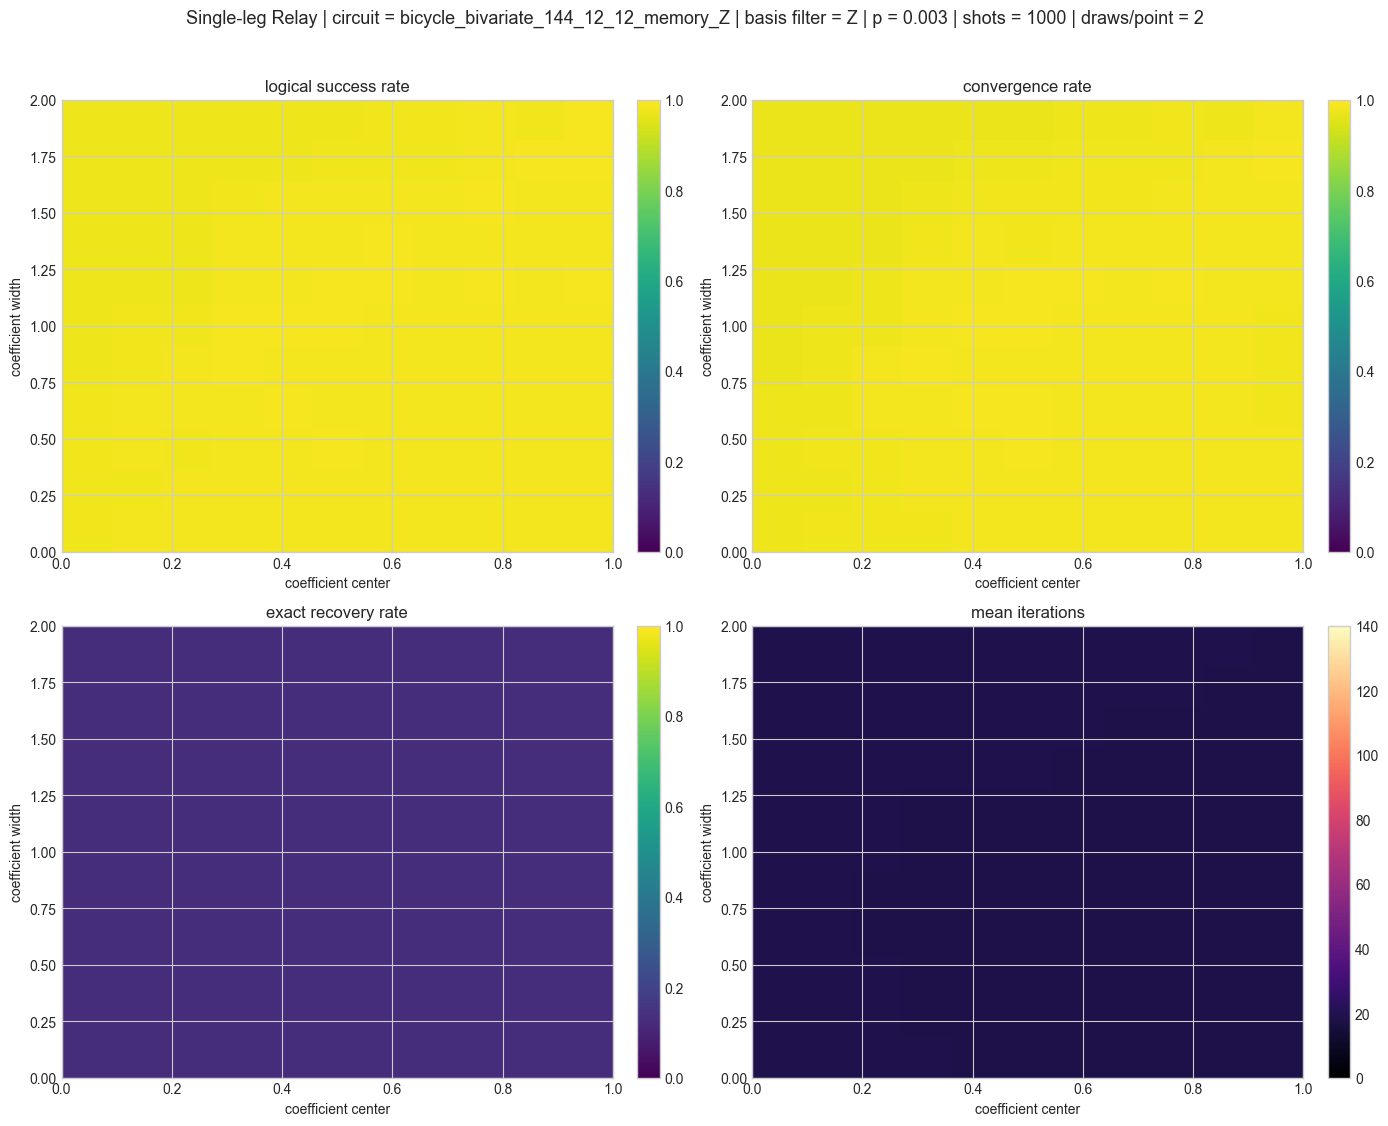

In [5]:
artifact = evaluate_parameter_heatmaps(sampled_error_data, check_matrices)
grid_df = grid_table(artifact)
best_df = best_points_table(grid_df)

display(best_df)
display(
    grid_df.sort_values(
        ["logical_success_rate", "convergence_rate", "mean_iterations"],
        ascending=[False, False, True],
    ).head(20)
)
plot_parameter_heatmaps(artifact);
plt.show()